<a href="https://colab.research.google.com/github/MahsanGhalami/Fundamentals-of-Intelligent-Systems-4041/blob/main/mini1/Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
RocCurveDisplay, accuracy_score
)
import tensorflow as tf
from tensorflow import keras


In [ ]:
df=pd.read_csv('/content/teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


##Data Exploration & Visualization

INFO AND DESCRIBE

In [ ]:
df.info()
df.describe()
#df['reside'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   1000 non-null   int64  
 1   tenure   1000 non-null   int64  
 2   age      1000 non-null   int64  
 3   marital  1000 non-null   int64  
 4   address  1000 non-null   int64  
 5   income   1000 non-null   float64
 6   ed       1000 non-null   int64  
 7   employ   1000 non-null   int64  
 8   retire   1000 non-null   float64
 9   gender   1000 non-null   int64  
 10  reside   1000 non-null   int64  
 11  custcat  1000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 93.9 KB


,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.0220,35.526000,41.684000,0.495000,11.551000,77.535000,2.671000,10.987000,0.047000,0.517000,2.331000,2.487000
std,0.8162,21.359812,12.558816,0.500225,10.086681,107.044165,1.222397,10.082087,0.211745,0.499961,1.435793,1.120306
min,1.0000,1.000000,18.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.0000,17.000000,32.000000,0.000000,3.000000,29.000000,2.000000,3.000000,0.000000,0.000000,1.000000,1.000000
50%,2.0000,34.000000,40.000000,0.000000,9.000000,47.000000,3.000000,8.000000,0.000000,1.000000,2.000000,3.000000
75%,3.0000,54.000000,51.000000,1.000000,18.000000,83.000000,4.000000,17.000000,0.000000,1.000000,3.000000,3.000000
max,3.0000,72.000000,77.000000,1.000000,55.000000,1668.000000,5.000000,47.000000,1.000000,1.000000,8.000000,4.000000


Finding null values

In [ ]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts

,0
region,0
tenure,0
age,0
marital,0
address,0
income,0
ed,0
employ,0
retire,0
gender,0


selecting X ,Y

In [ ]:
y=df['custcat']
x=df.drop('custcat',axis=1)

##Correlation Matrix

Text(0.5, 1.0, 'Correlation ')

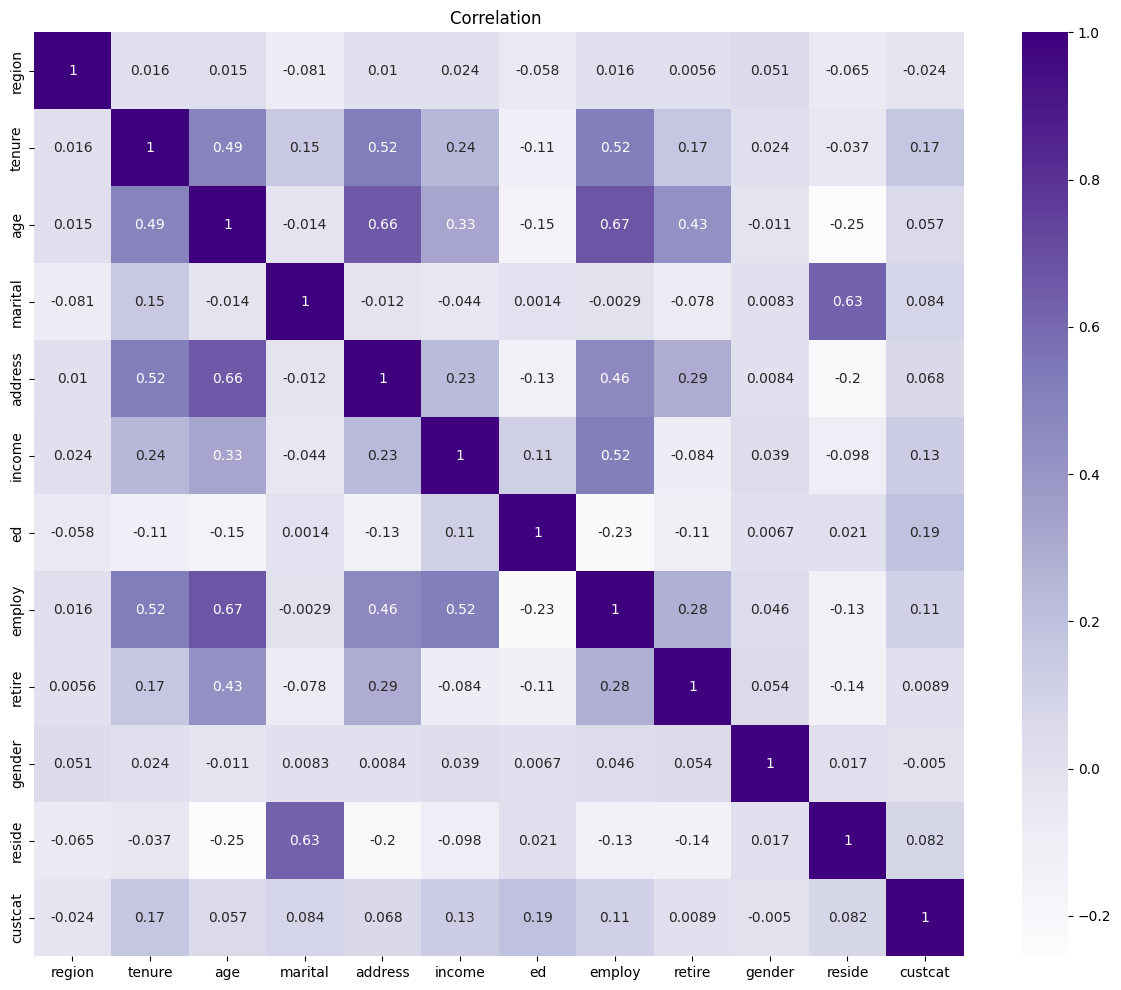

In [ ]:
corr=df.corr()
fig = plt.figure(figsize=(15,12))
r = sns.heatmap(corr, cmap='Purples' , annot=True)
r.set_title("Correlation ")


# Pairplot & Distribution Patterns


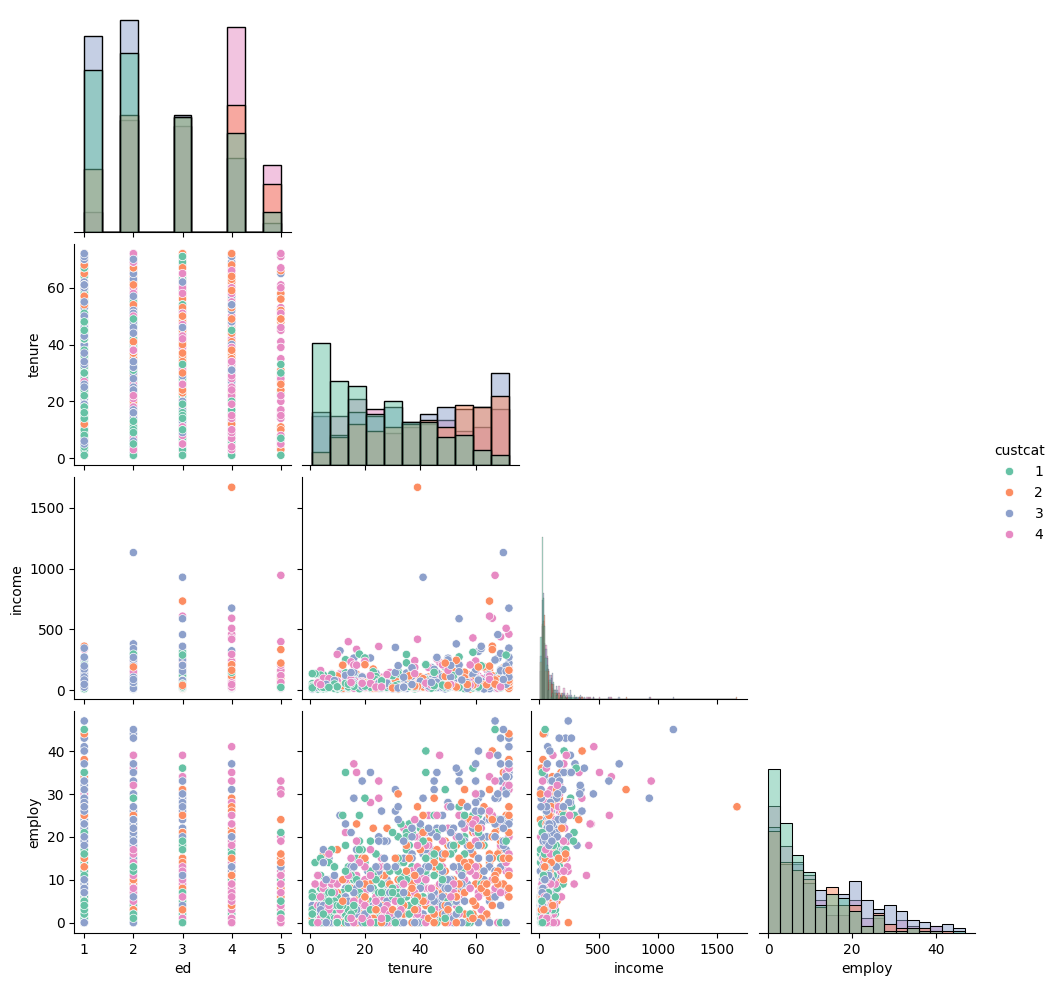

In [ ]:
pp =['ed','tenure','income','employ','custcat']
sns.pairplot(df[pp], hue=pp[-1], corner=True, diag_kind='hist',palette='Set2')

#Boxplots (Feature vs Class)


/tmp/ipython-input-1066535344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='custcat', y=col,palette='Set2')


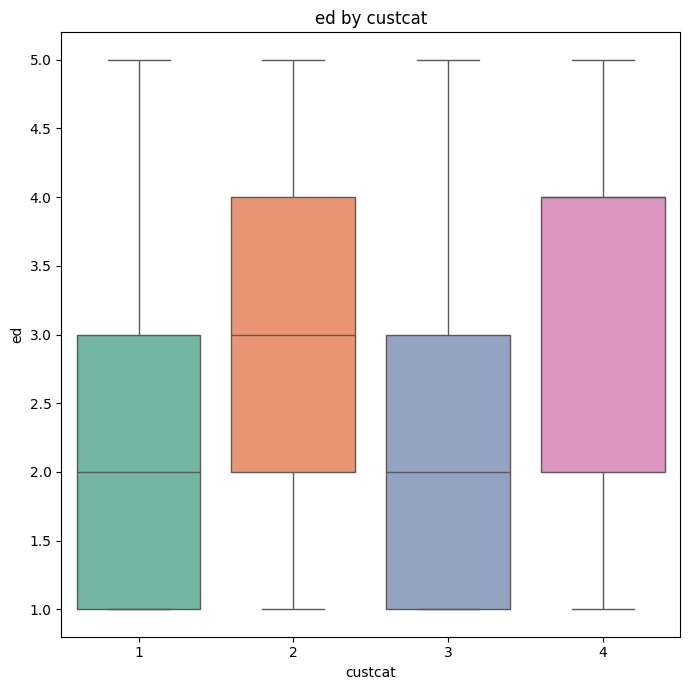

/tmp/ipython-input-1066535344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='custcat', y=col,palette='Set2')


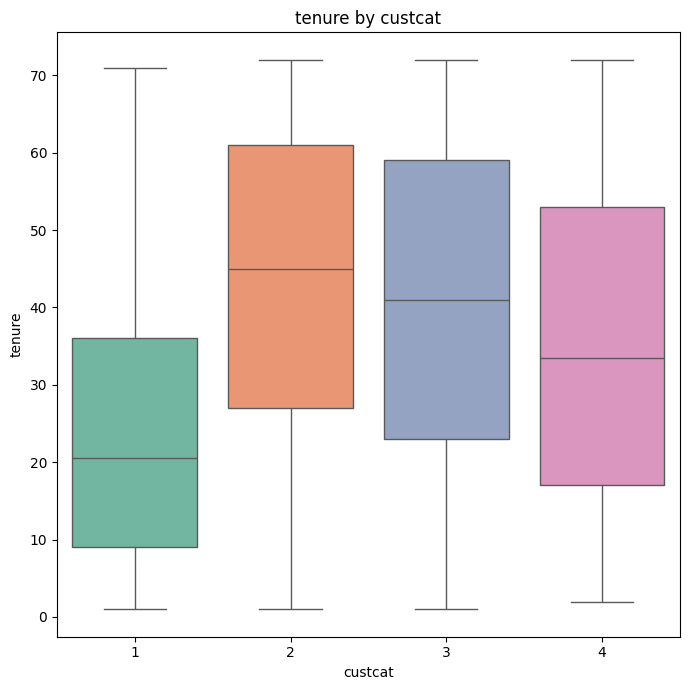

/tmp/ipython-input-1066535344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='custcat', y=col,palette='Set2')


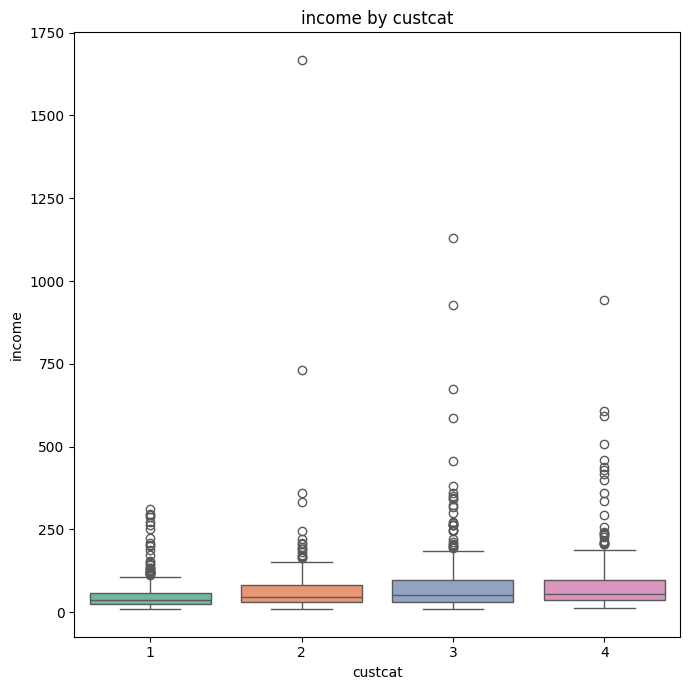

/tmp/ipython-input-1066535344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='custcat', y=col,palette='Set2')


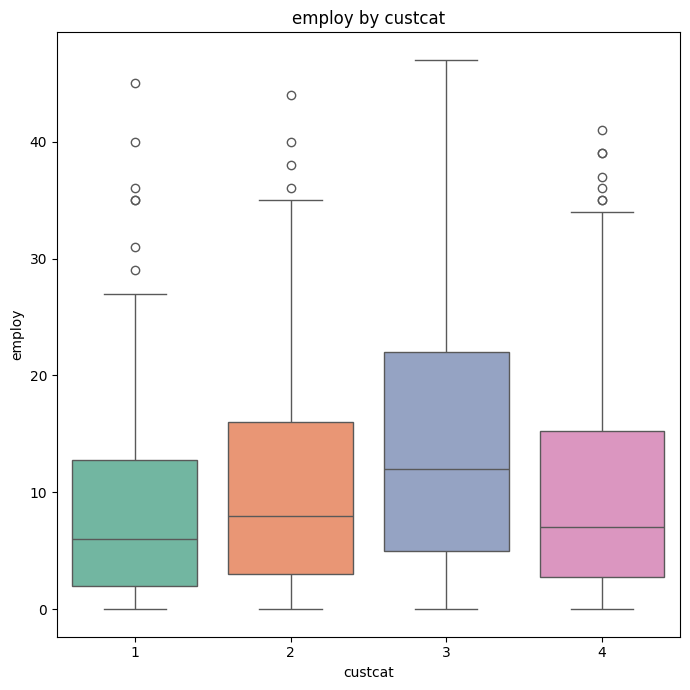

In [ ]:
for col in pp[0:4]:
    plt.figure(figsize=(7,7))
    sns.boxplot(data=df, x='custcat', y=col,palette='Set2')
    plt.title(f'{col} by custcat')
    plt.tight_layout()
    plt.show()


# Hexbin Visualizations (Density + Class Mean)


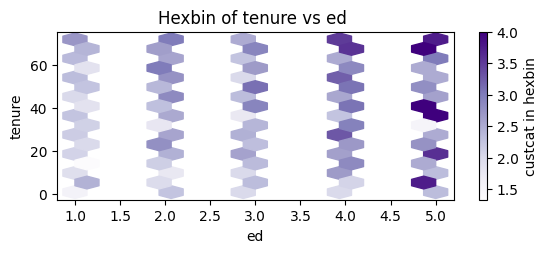

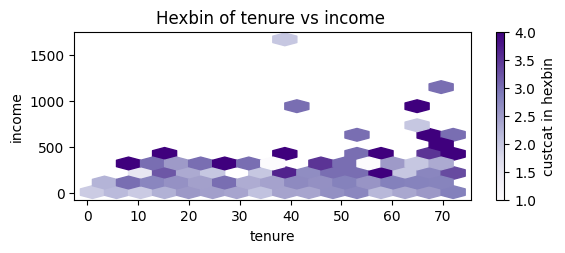

In [ ]:
plt.subplot(211)
hb = plt.hexbin(df['ed'], df['tenure'],
                C=df['custcat'],reduce_C_function=np.mean,
                gridsize=15, cmap='Purples')
plt.ylabel('tenure')
plt.xlabel('ed')
cb = plt.colorbar(hb)
cb.set_label('custcat in hexbin')
plt.title('Hexbin of tenure vs ed ')

plt.show()
plt.subplot(212)
hb = plt.hexbin( df['tenure'],df['income'],
                C=df['custcat'],reduce_C_function=np.mean,
                gridsize=15, cmap='Purples')
plt.ylabel('income')
plt.xlabel('tenure')
cb = plt.colorbar(hb)
cb.set_label('custcat in hexbin')
plt.title('Hexbin of tenure vs income ')
plt.show()

/tmp/ipython-input-2636266573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, data=df, palette='Set2')


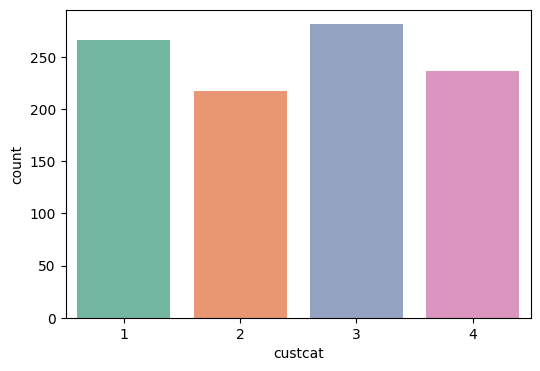

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y, data=df, palette='Set2')

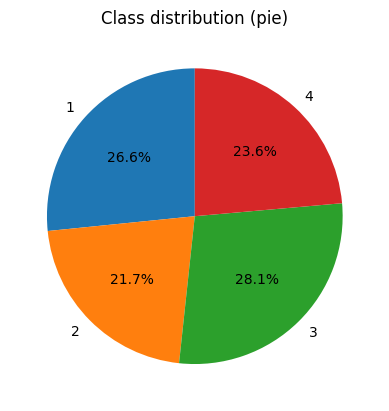

,count
custcat,
1,266
2,217
3,281
4,236


In [ ]:
counts = df['custcat'].value_counts().sort_index()
plt.pie(counts, labels=[str(k) for k in counts.index],
        autopct='%1.1f%%', startangle=90)
plt.title('Class distribution (pie)')
plt.show()
counts

## preprossesing

In [ ]:
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)


In [ ]:
selector = VarianceThreshold(threshold=0.4)
selector.fit(x_train_scaled)
selector.get_support()


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

lasso feature selection

In [ ]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

l1cv = LogisticRegressionCV(
    Cs=[0.01, 0.1, 1, 10],
    penalty='l1',
    solver='saga',
    cv=5
)

l1cv.fit(x_train_scaled, y_train)
print("Best C (per-class):", l1cv.C_)

coef_df = pd.DataFrame(l1cv.coef_, columns=x.columns, index=l1cv.classes_)
l1selected = coef_df.columns[(coef_df != 0).any(axis=0)].tolist()
print(f"{len(l1selected)} selected features:", l1selected)

Xtr_l1 = pd.DataFrame(x_train_scaled, columns=x.columns)[l1selected]
Xte_l1 = pd.DataFrame(x_test_scaled,  columns=x.columns)[l1selected]

final_logit = LogisticRegression()
final_logit.fit(Xtr_l1, y_train)

from sklearn.metrics import accuracy_score
y_pred_l1= final_logit.predict(Xte_l1)
print("Test accuracy (LassoCV):", accuracy_score(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1))

Best C (per-class): [0.1 0.1 0.1 0.1]
9 selected features: ['region', 'tenure', 'age', 'income', 'ed', 'employ', 'retire', 'gender', 'reside']
Test accuracy (LassoCV): 0.4
              precision    recall  f1-score   support

           1       0.42      0.44      0.43        54
           2       0.31      0.28      0.29        40
           3       0.43      0.39      0.41        62
           4       0.41      0.48      0.44        44

    accuracy                           0.40       200
   macro avg       0.39      0.40      0.39       200
weighted avg       0.40      0.40      0.40       200



In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


base_logit = LogisticRegression()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=base_logit, step=1, cv=cv5, scoring='accuracy')
rfecv.fit(x_train_scaled, y_train)

print(rfecv.support_)
rfecv_selected = x.columns[rfecv.support_].tolist()
print("Selected by RFECV:", rfecv_selected)

Xtr_rfe = pd.DataFrame(x_train_scaled, columns=x.columns)[rfecv_selected]
Xte_rfe = pd.DataFrame(x_test_scaled,  columns=x.columns)[rfecv_selected]

final_logit = LogisticRegression()
final_logit.fit(Xtr_rfe, y_train)

from sklearn.metrics import accuracy_score
y_pred_rfe = final_logit.predict(Xte_rfe)
print("Test accuracy (RFECV):", accuracy_score(y_test, y_pred_rfe))
print(classification_report(y_test, y_pred_rfe))

[ True  True  True False False False  True  True False False  True]
Selected by RFECV: ['region', 'tenure', 'age', 'ed', 'employ', 'reside']
Test accuracy (RFECV): 0.375
              precision    recall  f1-score   support

           1       0.42      0.46      0.44        54
           2       0.24      0.23      0.23        40
           3       0.42      0.35      0.38        62
           4       0.37      0.43      0.40        44

    accuracy                           0.38       200
   macro avg       0.36      0.37      0.36       200
weighted avg       0.37      0.38      0.37       200



In [ ]:
def eval_and_plot(y_test, y_pred, y_proba, classes, title_prefix="Model"):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'{title_prefix} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    y_test_ohe = pd.get_dummies(y_test).reindex(columns=classes, fill_value=0)

    auc_macro = roc_auc_score(y_test_ohe, y_proba, average='macro', multi_class='ovr')
    auc_weighted = roc_auc_score(y_test_ohe, y_proba, average='weighted', multi_class='ovr')

    print(f"{title_prefix} — Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"{title_prefix} — ROC-AUC macro: {auc_macro:.4f} | weighted: {auc_weighted:.4f}")
    print(classification_report(y_test, y_pred, digits=4))


In [ ]:
final_logit_l1 = LogisticRegression()
final_logit_l1.fit(Xtr_l1, y_train)

y_proba_l1 = final_logit_l1.predict_proba(Xte_l1)

In [ ]:
final_logit_rfe = LogisticRegression()
final_logit_rfe.fit(Xtr_rfe, y_train)

y_proba_rfe = final_logit_rfe.predict_proba(Xte_rfe)


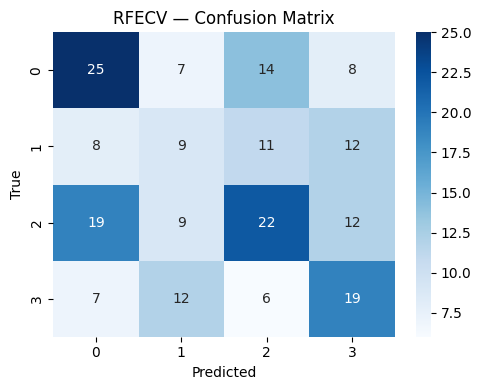

RFECV — Accuracy: 0.3750
RFECV — ROC-AUC macro: 0.6801 | weighted: 0.6820
              precision    recall  f1-score   support

           1     0.4237    0.4630    0.4425        54
           2     0.2432    0.2250    0.2338        40
           3     0.4151    0.3548    0.3826        62
           4     0.3725    0.4318    0.4000        44

    accuracy                         0.3750       200
   macro avg     0.3637    0.3687    0.3647       200
weighted avg     0.3737    0.3750    0.3728       200



In [ ]:
eval_and_plot(y_test, y_pred_rfe, y_proba_rfe, final_logit.classes_, title_prefix="RFECV")

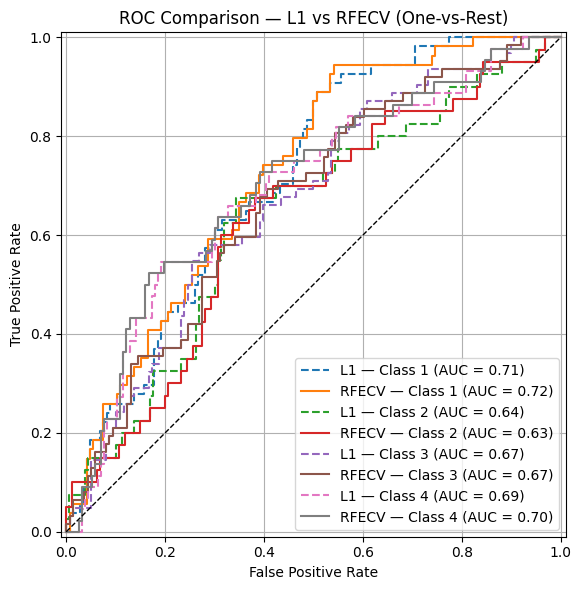

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

classes = np.unique(y_test)

for i, cls in enumerate(classes):
    # L1
    RocCurveDisplay.from_predictions(
        (y_test == cls).astype(int),   # converting to binary
        y_proba_l1[:, i],
        name=f"L1 — Class {cls}",
        ax=plt.gca(),
        linestyle="--"
    )

    # RFECV
    RocCurveDisplay.from_predictions(
        (y_test == cls).astype(int),
        y_proba_rfe[:, i],
        name=f"RFECV — Class {cls}",
        ax=plt.gca()
    )

plt.plot([0,1],[0,1],'k--',linewidth=1)
plt.title("ROC Comparison — L1 vs RFECV (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


Top-10 most influential features (global):
ed        0.470357
tenure    0.344529
employ    0.193055
age       0.108477
reside    0.103141
region    0.098234
dtype: float64


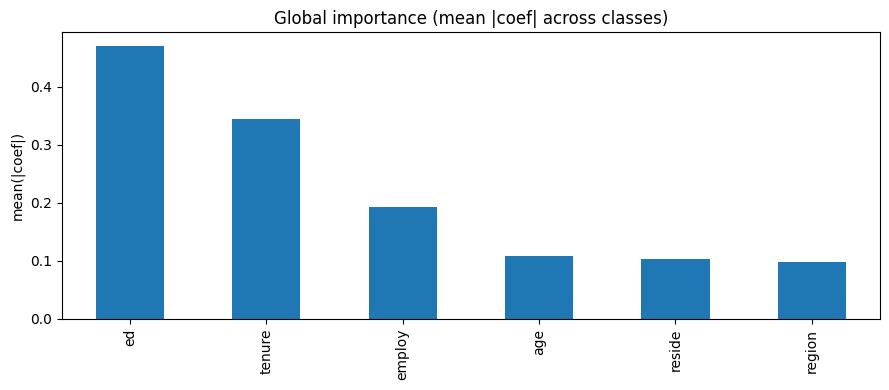

In [ ]:

feat_names = Xtr_rfe.columns.tolist()
coefs = pd.DataFrame(final_logit.coef_, columns=feat_names, index=final_logit.classes_)

global_importance = coefs.abs().mean(axis=0).sort_values(ascending=False)
print("Top-10 most influential features (global):")
print(global_importance.head(10))


global_importance.head(10).plot(kind='bar', figsize=(9,4))
plt.title('Global importance (mean |coef| across classes)')
plt.ylabel('mean(|coef|)')
plt.tight_layout()
plt.show()


PCA

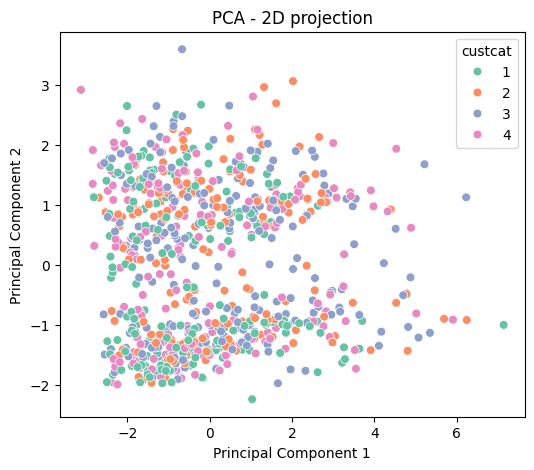

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_train_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette='Set2', s=40)
plt.title("PCA - 2D projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


LDA

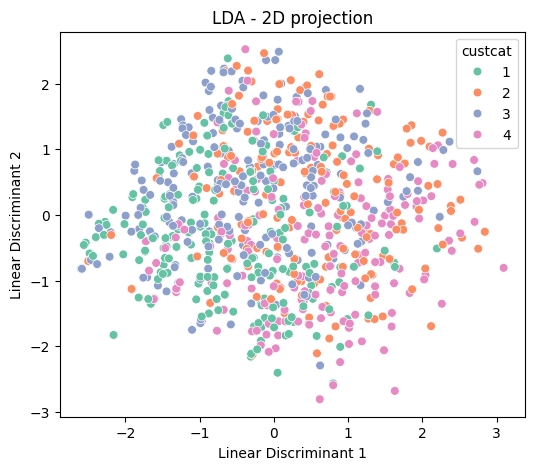

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_lda = lda.fit_transform(x_train_scaled, y_train)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y_train, palette='Set2', s=40)
plt.title("LDA - 2D projection")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.show()


MLP

In [ ]:
# ===== 1) Imports =====
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
y_train_indexed = y_train - 1
y_test_indexed = y_test - 1
#n_in  = x_train_scaled.shape[1]
#n_out = int(np.unique(y_train_indexed).size)
n_in  = x_train_scaled.shape[1]
n_out = len(np.unique(y_train_indexed))


In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    x_train_scaled, y_train_indexed, test_size=0.2, random_state=42, stratify=y_train_indexed
)

#  class_weight
classes = np.unique(y_train_sub)
cw_vals = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_sub)  # docs: sklearn
class_weight = {c: w for c, w in zip(classes, cw_vals)}

#  Callbacks
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0)

# model
def build_model(units1=32, units2=16, units3=None, l2=1e-4, dropout=0.1, lr=5e-4):
    x_in = keras.Input(shape=(n_in,))
    x = layers.Dense(units1, activation='relu',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2))(x_in)          # He for ReLU
    x = layers.BatchNormalization()(x)                                      # BN
    if dropout > 0: x = layers.Dropout(dropout)(x)

    x = layers.Dense(units2, activation='relu',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)

    if units3 is not None and units3 > 0:
        x = layers.Dense(units3, activation='relu',
                         kernel_initializer='he_normal',
                         kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        if dropout > 0: x = layers.Dropout(dropout)(x)

    z    = layers.Dense(2, activation='linear', name='feat2d')(x)
    yout = layers.Dense(n_out, activation='softmax')(z)
    m    = keras.Model(x_in, yout)

    m.compile(optimizer=Adam(learning_rate=lr),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

# grid search
grid = {
    "units1":  [32, 64],
    "units2":  [16, 32],
    "units3":  [None, 8],
    "l2":      [1e-4, 1e-3],
    "dropout": [ 0.1, 0.2],
    "lr":      [1e-3, 5e-4, 3e-4],
    "batch":   [32, 64],
}

def iter_configs(grid):
    keys = list(grid.keys())
    for values in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

best = None
model_best = None
best_model = None


for hp in iter_configs(grid):
    m = build_model(units1=hp["units1"], units2=hp["units2"], units3=hp["units3"],
                    l2=hp["l2"], dropout=hp["dropout"], lr=hp["lr"])

    m.fit(X_train_sub, y_train_sub,
          validation_data=(X_val, y_val),
          epochs=150, batch_size=hp["batch"],
          callbacks=[es, reduce_lr],
          class_weight=class_weight,
          verbose=0)


    ypb_val  = m.predict(X_val, verbose=0)
    yhat_val = ypb_val.argmax(axis=1)
    acc = accuracy_score(y_val, yhat_val)
    auc = roc_auc_score(y_val, ypb_val, multi_class='ovr', average='macro')
    print(f"HP {hp} -> Val ACC={acc:.3f} | Val AUC={auc:.3f}")

    if (best is None) or (auc > best[2]):
        best = (hp, acc, auc)
        model_best = m
        best_model = m

print("\nBest on VAL:", best[0], "| ACC:", round(best[1],3), "| AUC:", round(best[2],3))


ypb_test  = best_model.predict(x_test_scaled, verbose=0)
yhat_test = ypb_test.argmax(axis=1)
test_acc  = accuracy_score(y_test_indexed, yhat_test)
test_auc  = roc_auc_score(y_test_indexed, ypb_test, multi_class='ovr', average='macro')
print(f"TEST  ACC={test_acc:.3f} | TEST AUC(macro, OVR)={test_auc:.3f}")


HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.001, 'batch': 32} -> Val ACC=0.344 | Val AUC=0.629
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.001, 'batch': 64} -> Val ACC=0.338 | Val AUC=0.645
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.0005, 'batch': 32} -> Val ACC=0.412 | Val AUC=0.663
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.0005, 'batch': 64} -> Val ACC=0.375 | Val AUC=0.683
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.0003, 'batch': 32} -> Val ACC=0.331 | Val AUC=0.557
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.1, 'lr': 0.0003, 'batch': 64} -> Val ACC=0.381 | Val AUC=0.641
HP {'units1': 32, 'units2': 16, 'units3': None, 'l2': 0.0001, 'dropout': 0.2, 'lr': 0.001, 'batch': 32} -> Val ACC=0.325 | Val AUC=0.654
HP {'units1': 32, 'units2': 16, 'unit

In [ ]:
best_model.summary()

Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_63 (InputLayer)     │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_213 (Dense)               │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_150         │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_150 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_214 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_151         │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_151 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat2d (Dense)                  │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_215 (Dense)               │ (None, 4)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,068 (19.80 KB)

 Trainable params: 1,646 (6.43 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 3,294 (12.87 KB)

(800, 2)


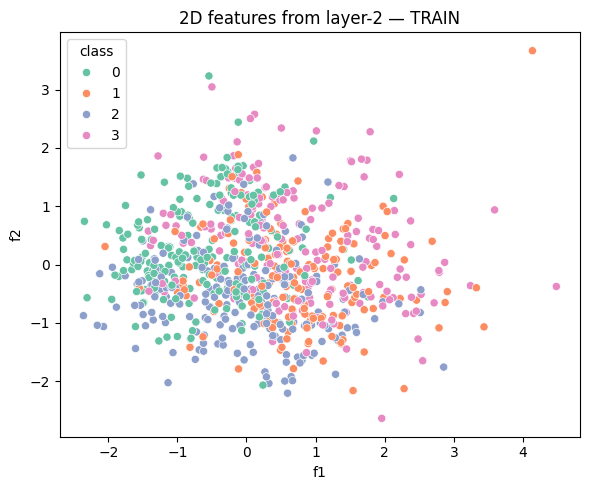

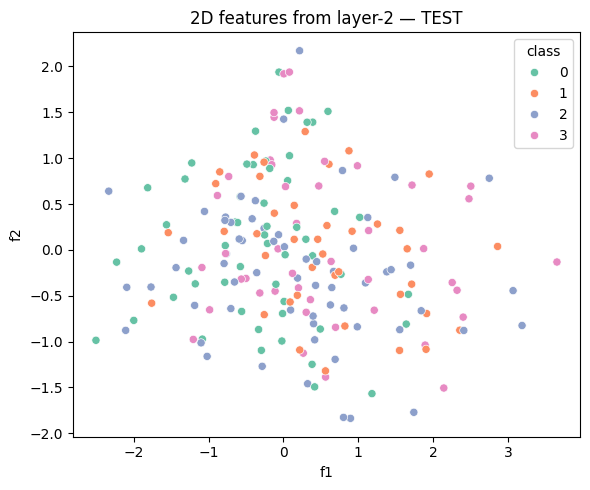

In [ ]:
feat_model = keras.Model(inputs=best_model.input, outputs=best_model.get_layer('feat2d').output)
Z_train_2d = feat_model.predict(x_train_scaled, verbose=0)
Z_test_2d  = feat_model.predict(x_test_scaled,  verbose=0)
print(Z_train_2d.shape)
plt.figure(figsize=(6,5))
sns.scatterplot(x=Z_train_2d[:,0], y=Z_train_2d[:,1], hue=y_train_indexed, s=35, palette='Set2')
plt.title("2D features from layer-2 — TRAIN"); plt.xlabel("f1"); plt.ylabel("f2"); plt.legend(title="class")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=Z_test_2d[:,0], y=Z_test_2d[:,1], hue=y_test_indexed, s=35, palette='Set2')
plt.title("2D features from layer-2 — TEST"); plt.xlabel("f1"); plt.ylabel("f2"); plt.legend(title="class")
plt.tight_layout(); plt.show()

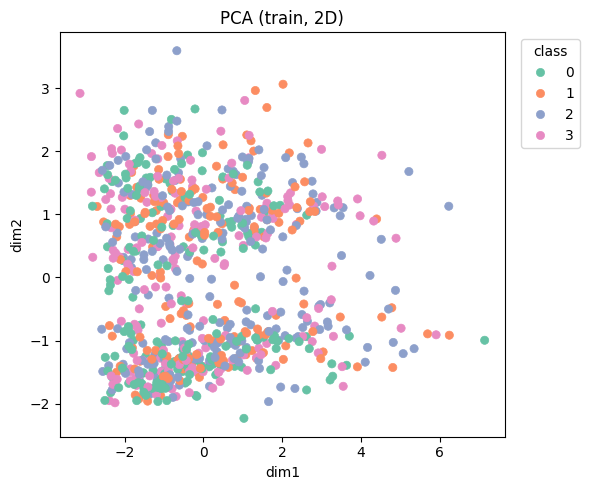

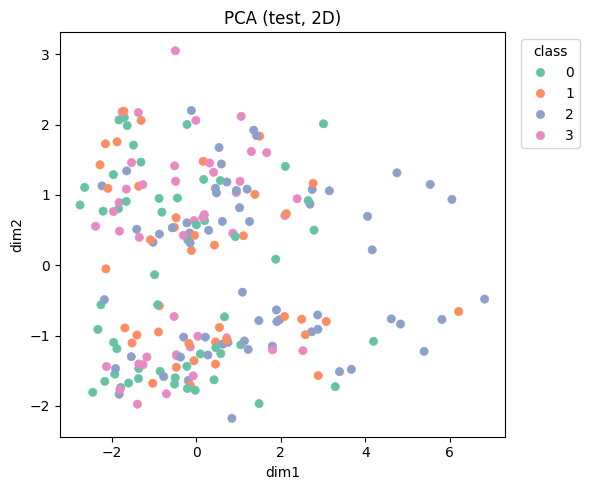

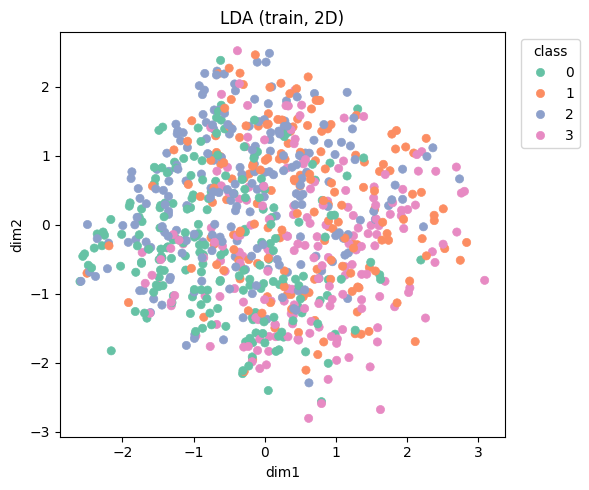

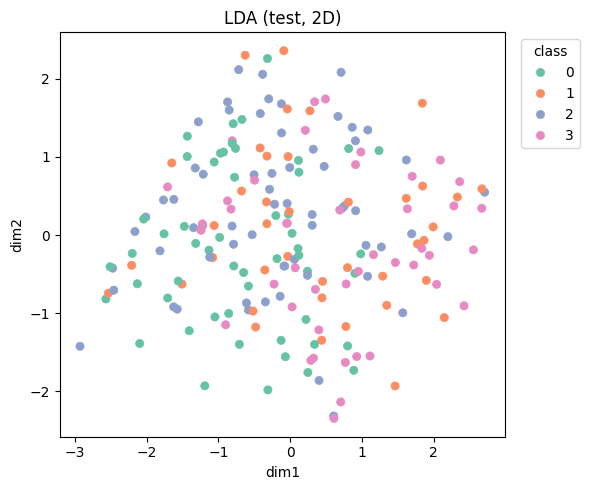

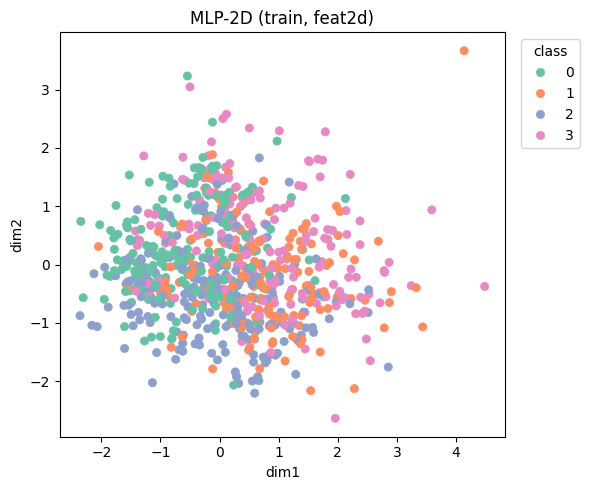

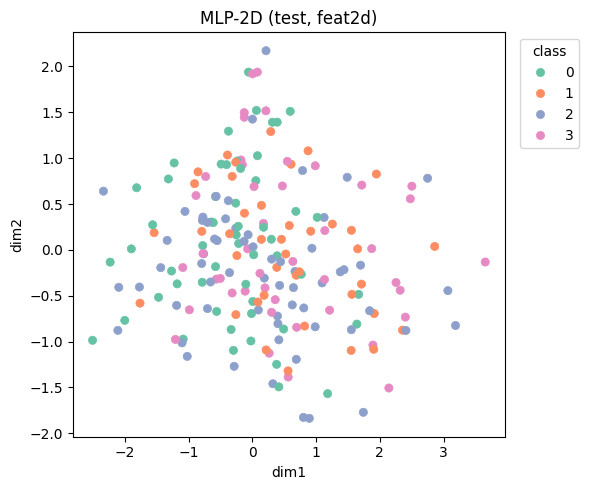

In [ ]:

import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


Xtr = x_train_scaled
Xte = x_test_scaled
ytr = y_train_indexed
yte = y_test_indexed

# PCA 2D
pca = PCA(n_components=2, random_state=42)
Ztr_pca = pca.fit_transform(Xtr)
Zte_pca = pca.transform(Xte)

# LDA
n_classes = int(np.unique(ytr).size)
lda_comps = 2 if n_classes >= 3 else 1
Ztr_lda_1d = None
Zte_lda_1d = None
Ztr_lda = None
Zte_lda = None
try:
    lda = LDA(n_components=lda_comps)
    Ztr_tmp = lda.fit_transform(Xtr, ytr)
    Zte_tmp = lda.transform(Xte)
    if lda_comps == 2:
        Ztr_lda, Zte_lda = Ztr_tmp, Zte_tmp
    else:

        Ztr_lda_1d, Zte_lda_1d = Ztr_tmp, Zte_tmp
        Ztr_lda = np.c_[Ztr_lda_1d, np.zeros_like(Ztr_lda_1d)]
        Zte_lda = np.c_[Zte_lda_1d, np.zeros_like(Zte_lda_1d)]
except Exception as e:
    print("LDA failed with:", repr(e))
    Ztr_lda = None
    Zte_lda = None

Ztr_mlp = Z_train_2d
Zte_mlp = Z_test_2d

def plot2d(Z, y, title):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=y, s=35, palette='Set2', edgecolor=None)
    plt.title(title); plt.xlabel("dim1"); plt.ylabel("dim2"); plt.legend(title="class", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout(); plt.show()

# (Train/Test)
plot2d(Ztr_pca, ytr, "PCA (train, 2D)")
plot2d(Zte_pca, yte, "PCA (test, 2D)")

if Ztr_lda is not None:
    ttl_tr = "LDA (train, 2D)" if lda_comps==2 else "LDA (train, 1D→2D padded)"
    ttl_te = "LDA (test, 2D)"  if lda_comps==2 else "LDA (test, 1D→2D padded)"
    plot2d(Ztr_lda, ytr, ttl_tr)
    plot2d(Zte_lda, yte, ttl_te)

plot2d(Ztr_mlp, ytr, "MLP-2D (train, feat2d)")
plot2d(Zte_mlp, yte, "MLP-2D (test, feat2d)")


